# Preregistered Route-3 7D Single-round NPE Ensemble

Three independently initialized MAF density estimators use the same independent
4,096-row bank, fixed train/validation split, and training-only scaler.
Proposal is the frozen seven-dimensional prior. The equal-weight mixture is
transparent; there are no sequential rounds or held-out-driven adjustments.

In [1]:
from __future__ import annotations
from datetime import datetime, timezone
import importlib.metadata as mdist
import json
import os
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "S4_sbi" / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "S4_sbi" / "src").exists():
            PROJECT_ROOT = parent
            break
for value in (PROJECT_ROOT / "S4_sbi" / "src", PROJECT_ROOT):
    if str(value) not in sys.path:
        sys.path.insert(0, str(value))

environment = {
    "executed_utc": datetime.now(timezone.utc).isoformat(),
    "conda_environment": os.environ.get("CONDA_DEFAULT_ENV"),
    "sys.executable": sys.executable,
    "sys.prefix": sys.prefix,
    "python": platform.python_version(),
    "kernel_id": "neurolib",
    "kernel_display_name": "Python (neurolib)",
    "numpy": mdist.version("numpy"),
    "torch": mdist.version("torch"),
    "sbi": mdist.version("sbi"),
    "neurolib": mdist.version("neurolib"),
}
assert Path(sys.prefix).name.lower() == "neurolib"
display(pd.DataFrame(environment.items(), columns=["item", "value"]))

,item,value
0,executed_utc,2026-07-28T00:50:44.259246+00:00
1,conda_environment,neurolib
2,sys.executable,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...
3,sys.prefix,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...
4,python,3.10.20
5,kernel_id,neurolib
6,kernel_display_name,Python (neurolib)
7,numpy,2.2.6
8,torch,2.5.1
9,sbi,0.26.1


In [2]:
from sleep_sbi.route3_7d_experiment import *
from sleep_sbi.route3_7d_training import *
from sleep_sbi.route3_7d_validation import freeze_heldout_criteria

print("Preregistration SHA-256:", verify_preregistration())
training = train_ensemble_7d()
display(pd.DataFrame(training["summary"]["members"]))

Preregistration SHA-256: 2cedb6a68de307ab2f9233b4009a8f58854316259b6c185aeb61af5efdcbc363


,seed,device,status,epochs_completed,best_epoch,best_validation_loss,final_train_loss,final_validation_loss,runtime_this_call_s,checkpoint,preregistration_hash
0,7330001,cpu,trained,291,290,-10.151314,-10.430866,-10.151314,94.443467,D:/Year3_Mao_Projects/sleep_loop/S4_sbi/result...,2cedb6a68de307ab2f9233b4009a8f58854316259b6c18...
1,7330002,cpu,trained,288,287,-10.257993,-10.197269,-10.257993,90.624693,D:/Year3_Mao_Projects/sleep_loop/S4_sbi/result...,2cedb6a68de307ab2f9233b4009a8f58854316259b6c18...
2,7330003,cpu,trained,300,299,-9.748489,-9.850675,-9.748489,88.510944,D:/Year3_Mao_Projects/sleep_loop/S4_sbi/result...,2cedb6a68de307ab2f9233b4009a8f58854316259b6c18...


## Training histories and validation-only diagnostics

Validation loss, boundary accumulation, finite/support rate, and ensemble
disagreement are engineering diagnostics. They do not determine the formal
scientific verdict, which remains locked until independent held-out validation.

,case,finite_rate,within_prior_rate,mean_normalized_median_error,boundary_sample_fraction,mean_posterior_std
member,,,,,,
0,15.5,1.0,1.0,0.133132,0.076508,0.120697
1,15.5,1.0,1.0,0.138850,0.083344,0.123214
2,15.5,1.0,1.0,0.131296,0.074982,0.120992


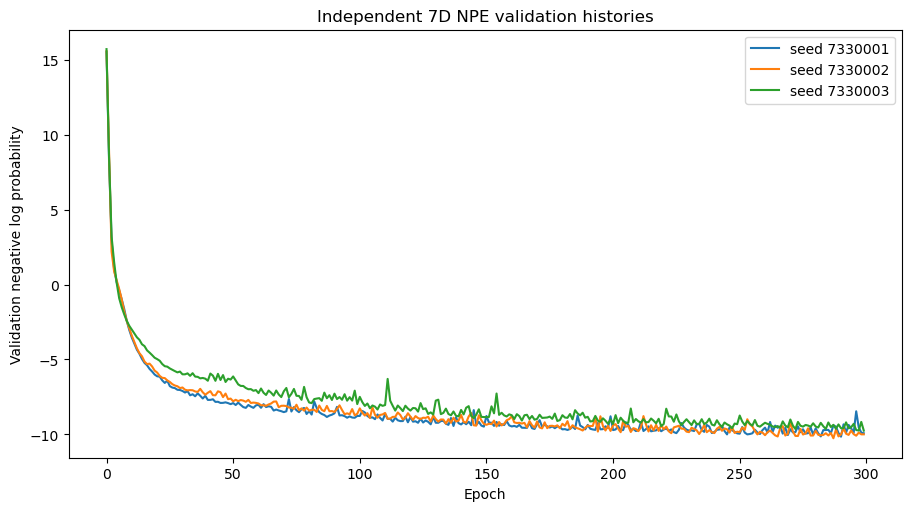

In [3]:
checks = validation_member_checks()
display(checks.groupby("member").mean(numeric_only=True))

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
for seed in model_seeds():
    history = pd.read_csv(TRAINING_ROOT / f"member_{seed}" / "training_history.csv")
    ax.plot(history.epoch, history.validation_loss, label=f"seed {seed}")
ax.set(xlabel="Epoch", ylabel="Validation negative log probability", title="Independent 7D NPE validation histories")
ax.legend()
figure_dir = TRAINING_ROOT / "figures"; figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / "validation_loss_curves.png", dpi=180)
fig.savefig(figure_dir / "validation_loss_curves.svg")
plt.show()

## Held-out criteria lock

The numerical criteria were already part of the immutable preregistration.
This separate artifact is copied and hashed before held-out theta, observations,
posterior samples, recovery, or PPC results are opened.

In [4]:
criteria = freeze_heldout_criteria()
print("Held-out criteria SHA-256:", criteria["sha256"])
display(pd.DataFrame([criteria["payload"]["criteria"]["formal_go"]]).T)

Held-out criteria SHA-256: 49a4f9590466a6d9ba83f83ee5b6783e268ba996f8e8fc7328e261fb0405edee


,0
preflight_failure_rate_max,0.01
training_failure_rate_max,0.01
heldout_failure_rate_max,0.01
posterior_finite_and_in_prior_rate_min,0.999
coverage_80_or_90_wilson_contains_nominal_parameters_min,6
severe_undercoverage_definition,observed coverage < nominal-0.15 and Wilson up...
severe_undercoverage_parameters_max,0
median_error_better_than_prior_parameters_min,6
overall_median_error_improvement_min_fraction,0.1
systematic_worsening_threshold,-0.05
